<center><h1>Gu_Xinpeng_HW2</h1></center>
<br>
<br>

Name: Xinpeng Gu
GitHub Username: marshg778
USC ID: 1678041153

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Get the Cycle Power Plant Data Set

In [3]:
df = pd.read_excel("CCPP/Folds5x2_pp.xlsx", sheet_name="Sheet1")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [6]:
print(df.shape)

(9568, 5)


#### ii. pairwise scatterplots of all the varianbles

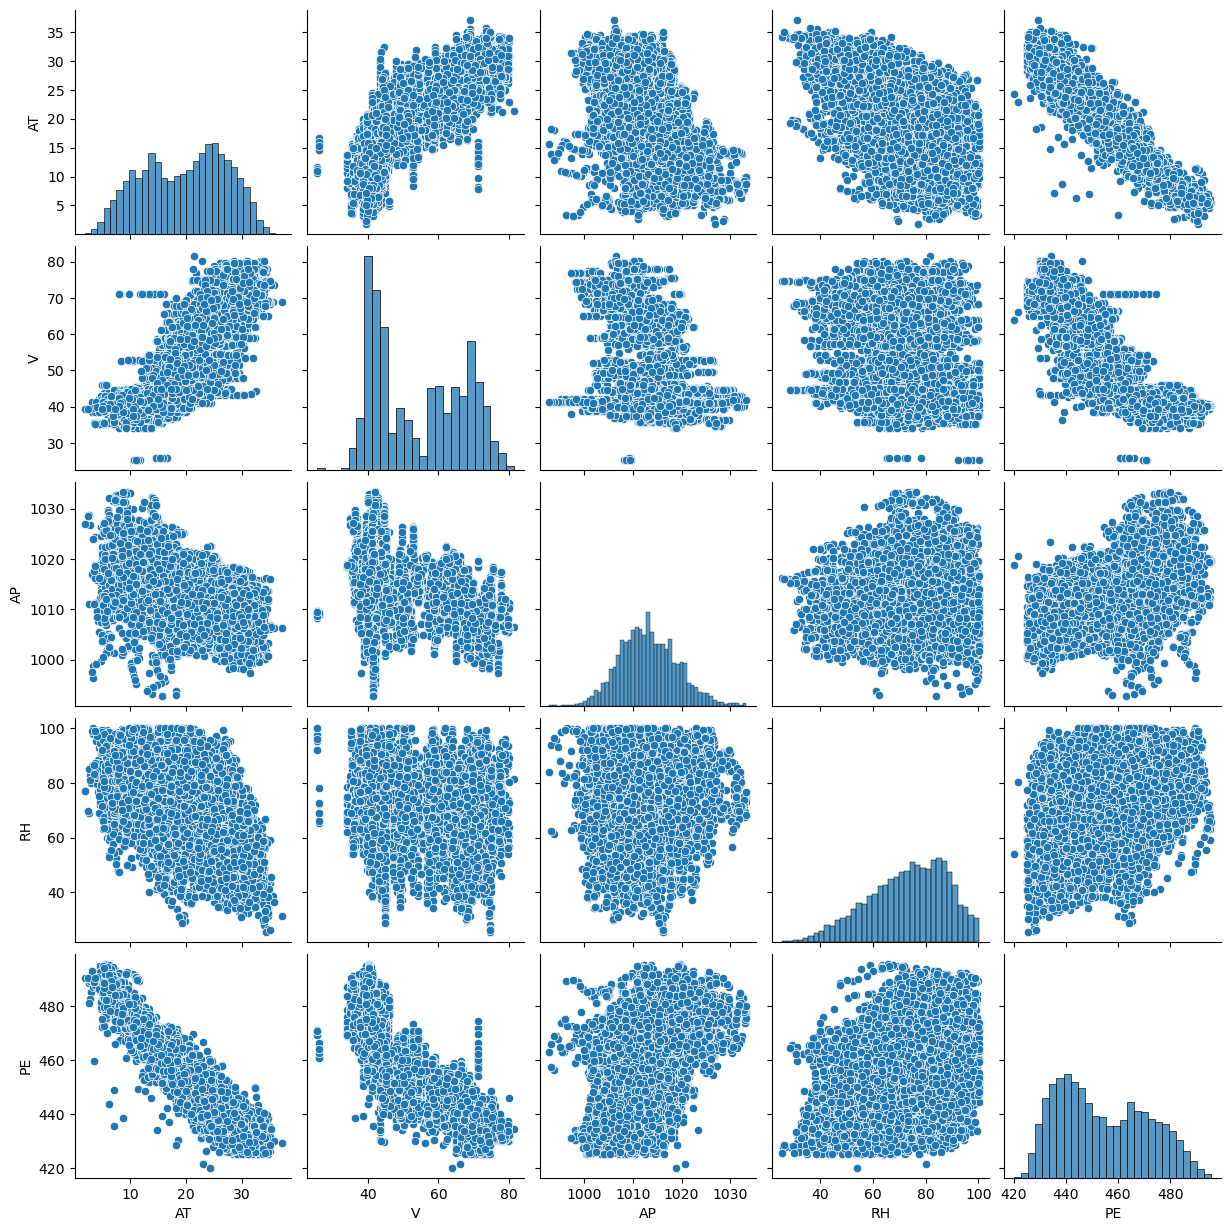

In [9]:
sns.pairplot(df)
plt.show()

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [11]:
summary = df.describe()
summary
summary.loc['range'] = summary.loc['max'] - summary.loc['min']
summary.loc['IQR'] = summary.loc['75%'] - summary.loc['25%']
summary

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000
range,35.300000,56.200000,40.410000,74.600000,75.500000
IQR,12.210000,24.800000,8.160000,21.502500,28.680000


### (c) Simple Linear Regression

===== Simple Linear Regression: PE ~ AT =====
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:02:47   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

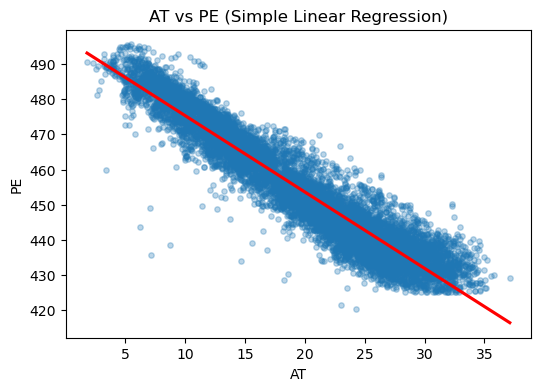

===== Simple Linear Regression: PE ~ V =====
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:02:49   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const  

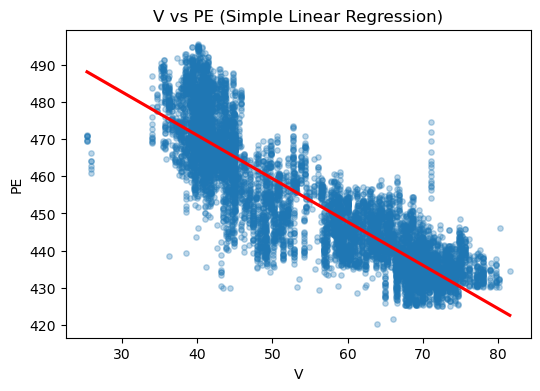

===== Simple Linear Regression: PE ~ AP =====
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:02:50   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

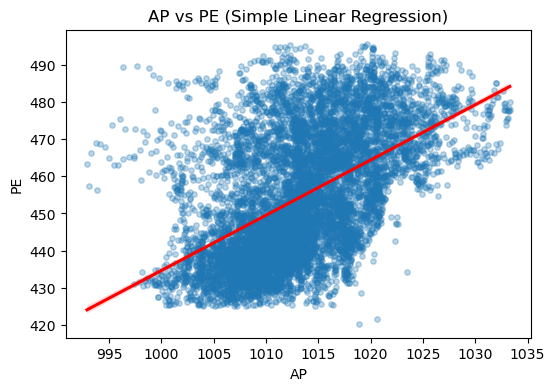

===== Simple Linear Regression: PE ~ RH =====
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:02:52   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const 

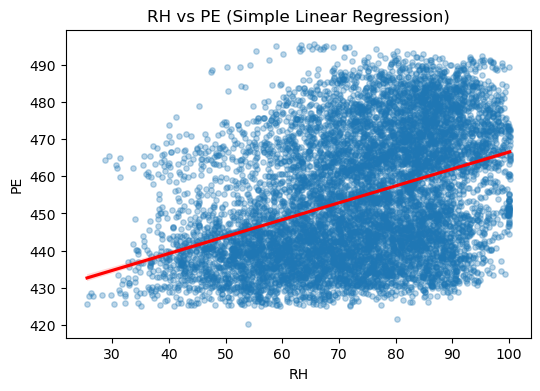

In [17]:
import statsmodels.api as sm

predictors = ['AT', 'V', 'AP', 'RH']

for col in predictors:
    X = df[col]
    X = sm.add_constant(X)
    y = df['PE']
    model = sm.OLS(y, X).fit()
    print(f"===== Simple Linear Regression: PE ~ {col} =====")
    print(model.summary())
    print("\n")

    plt.figure(figsize=(6, 4))
    sns.regplot(x=col, y='PE', data=df, scatter_kws={'alpha': 0.3, 's': 15}, line_kws={'color': 'red'})
    plt.title(f'{col} vs PE (Simple Linear Regression)')
    plt.xlabel(col)
    plt.ylabel('PE')
    plt.show()

### (d) Multiple Regression

In [19]:
X_multi = df[predictors] 
X_multi = sm.add_constant(X_multi)
y = df['PE']

model_multi = sm.OLS(y, X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:03:05   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

### (e) 1c Compare to 1d

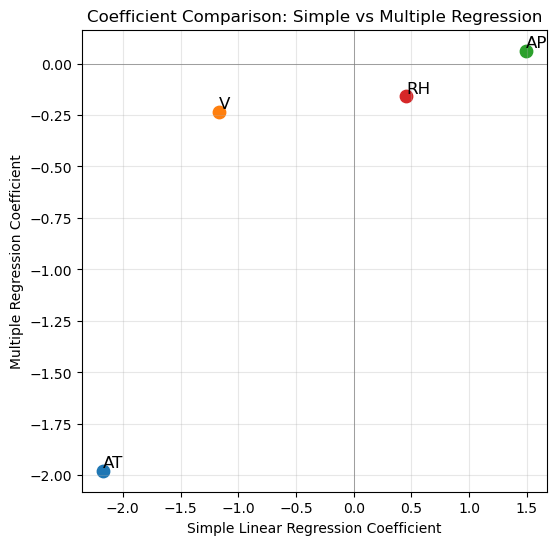

In [21]:
simple_coefs = {}
for col in predictors:
    X = sm.add_constant(df[col])
    y = df['PE']
    m = sm.OLS(y, X).fit()
    simple_coefs[col] = m.params[col] 

multi_coefs = model_multi.params[predictors] 

plt.figure(figsize=(6, 6))
for col in predictors:
    plt.scatter(simple_coefs[col], multi_coefs[col], s=80)
    plt.text(simple_coefs[col], multi_coefs[col], col, fontsize=12, ha='left', va='bottom')

plt.xlabel('Simple Linear Regression Coefficient')
plt.ylabel('Multiple Regression Coefficient')
plt.title('Coefficient Comparison: Simple vs Multiple Regression')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()


### (f) Nonlinear Association

In [23]:
for col in predictors:
    X = df[col]
    X_poly = pd.DataFrame({
        col: X,
        f'{col}^2': X**2,
        f'{col}^3': X**3
    })
    X_poly = sm.add_constant(X_poly)
    y = df['PE']

    model_poly = sm.OLS(y, X_poly).fit()
    print(f"===== Cubic Model: PE ~ {col} + {col}^2 + {col}^3 =====")
    print(model_poly.summary())
    print("\n")


===== Cubic Model: PE ~ AT + AT^2 + AT^3 =====
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:03:59   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

### (g) Interactions of Predictors

In [27]:
formula = 'PE ~ (AT + V + AP + RH) ** 2'
model_interact = smf.ols(formula=formula, data=df).fit()
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:04:55   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

### (h) Improvement

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
print(f"Train size: {train_df.shape[0]}, Test size: {test_df.shape[0]}")
formula_base = 'PE ~ AT + V + AP + RH'
model_base = smf.ols(formula=formula_base, data=train_df).fit()

pred_train_base = model_base.predict(train_df)
pred_test_base = model_base.predict(test_df)

mse_train_base = mean_squared_error(train_df['PE'], pred_train_base)
mse_test_base = mean_squared_error(test_df['PE'], pred_test_base)

print(f"Base Model - Train MSE: {mse_train_base:.4f}, Test MSE: {mse_test_base:.4f}")
formula_full = 'PE ~ (AT + V + AP + RH)**2 + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)'
model_full = smf.ols(formula=formula_full, data=train_df).fit()
print(model_full.summary())

Train size: 6697, Test size: 2871
Base Model - Train MSE: 20.5808, Test MSE: 21.2399
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:05:40   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

In [31]:
formula_reduced = 'PE ~ AT + V + AP + RH + AT:V + AT:RH + AP:RH + I(AT**2) + I(AP**2) + I(RH**2)'
model_reduced = smf.ols(formula=formula_reduced, data=train_df).fit()
print(model_reduced.summary())
pred_train_reduced = model_reduced.predict(train_df)
pred_test_reduced = model_reduced.predict(test_df)

mse_train_reduced = mean_squared_error(train_df['PE'], pred_train_reduced)
mse_test_reduced = mean_squared_error(test_df['PE'], pred_test_reduced)

print(f"Reduced Model - Train MSE: {mse_train_reduced:.4f}, Test MSE: {mse_test_reduced:.4f}")

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                 1.017e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:06:35   Log-Likelihood:                -19166.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6686   BIC:                         3.843e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.046e+04   1091.512     -9.581      0.0

### (i) KNN

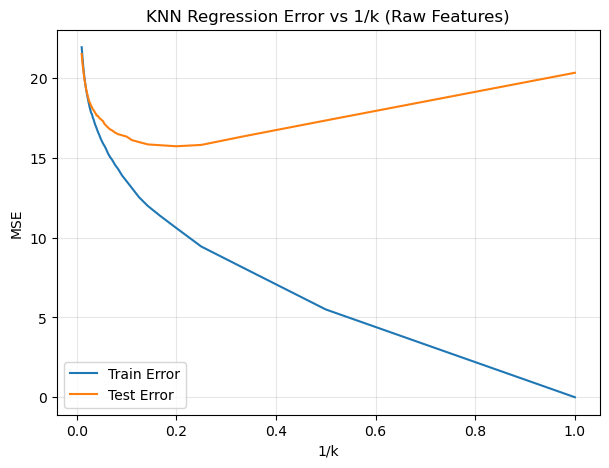

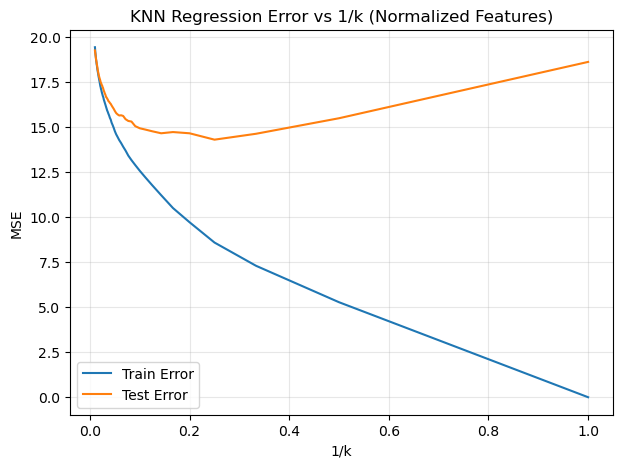

Raw features - Best k: 5, Test MSE: 15.7268
Normalized features - Best k: 4, Test MSE: 14.3057


In [33]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

X_train_raw = train_df[predictors]
X_test_raw = test_df[predictors]
y_train = train_df['PE']
y_test = test_df['PE']

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)

k_values = range(1, 101)

train_errors_raw, test_errors_raw = [], []
train_errors_norm, test_errors_norm = [], []

for k in k_values:
    knn_raw = KNeighborsRegressor(n_neighbors=k)
    knn_raw.fit(X_train_raw, y_train)
    train_errors_raw.append(mean_squared_error(y_train, knn_raw.predict(X_train_raw)))
    test_errors_raw.append(mean_squared_error(y_test, knn_raw.predict(X_test_raw)))

    knn_norm = KNeighborsRegressor(n_neighbors=k)
    knn_norm.fit(X_train_norm, y_train)
    train_errors_norm.append(mean_squared_error(y_train, knn_norm.predict(X_train_norm)))
    test_errors_norm.append(mean_squared_error(y_test, knn_norm.predict(X_test_norm)))

inv_k = [1/k for k in k_values]

plt.figure(figsize=(7, 5))
plt.plot(inv_k, train_errors_raw, label='Train Error')
plt.plot(inv_k, test_errors_raw, label='Test Error')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression Error vs 1/k (Raw Features)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(inv_k, train_errors_norm, label='Train Error')
plt.plot(inv_k, test_errors_norm, label='Test Error')
plt.xlabel('1/k')
plt.ylabel('MSE')
plt.title('KNN Regression Error vs 1/k (Normalized Features)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_k_raw = k_values[test_errors_raw.index(min(test_errors_raw))]
best_k_norm = k_values[test_errors_norm.index(min(test_errors_norm))]

print(f"Raw features - Best k: {best_k_raw}, Test MSE: {min(test_errors_raw):.4f}")
print(f"Normalized features - Best k: {best_k_norm}, Test MSE: {min(test_errors_norm):.4f}")

### (j ) Compare KNN and Linear

In [35]:
comparison = pd.DataFrame({
    'Model': ['Linear - Base', 'Linear - Reduced (interactions+quadratic)', 
              f'KNN Raw (k={best_k_raw})', f'KNN Normalized (k={best_k_norm})'],
    'Test MSE': [mse_test_base, mse_test_reduced, 
                 min(test_errors_raw), min(test_errors_norm)]
})
comparison = comparison.sort_values('Test MSE').reset_index(drop=True)
print(comparison)

                                       Model   Test MSE
0                       KNN Normalized (k=4)  14.305669
1                              KNN Raw (k=5)  15.726820
2  Linear - Reduced (interactions+quadratic)  18.694346
3                              Linear - Base  21.239857


## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.


A flexible method would generally perform better. When the sample size is very large, there is sufficient data to estimate the additional parameters required by a flexible model without incurring excessive variance. Because a flexible method can adapt more closely to the true underlying relationship, it typically achieves lower bias. With p small, there is little risk of overfitting due to high dimensionality, so the large n allows the flexible method to fully exploit its lower-bias advantage while keeping variance in check.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

An inflexible method would generally perform better. With very few observations relative to the number of predictors, a flexible method is highly prone to overfitting: it has enough parameters to fit noise in the training data rather than the true signal, resulting in very high variance and poor generalization to new data. An inflexible method, being more constrained, is less sensitive to this small-sample instability and tends to generalize better in this high-dimension, low-sample-size setting.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible method would generally perform better. An inflexible method assumes a rigid functional form and cannot adequately capture non-linear structure in the data, resulting in high bias regardless of sample size. A flexible method can adapt to the curvature and complexity of the true relationship, substantially reducing bias, which outweighs the associated increase in variance.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

An inflexible method would generally perform better. When the irreducible error is very large, a flexible method tends to fit the noise present in the training data rather than the true underlying pattern, since it is highly sensitive to fluctuations in the data. This leads to high variance and poor performance on new data. An inflexible method is less sensitive to this noise and produces more stable, generalizable predictions in the presence of high error variance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

Distances from (0,0,0): Obs.1 = 3.00, Obs.2 = 2.00, Obs.3 = 3.16, Obs.4 = 2.24, Obs.5 = 1.41, Obs.6 = 1.73.

### (b) What is our prediction with K = 1? Why?

Prediction: Green. With K=1, we use only the single nearest neighbor, which is Obs.5 (distance = 1.41, Y = Green).

### (c) What is our prediction with K = 3? Why?

Prediction: Red. With K=3, the three nearest neighbors are Obs.5 (Green), Obs.6 (Red), and Obs.2 (Red). Majority vote gives Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect the best K to be small. A small K produces a more flexible, locally-adaptive decision boundary capable of capturing high non-linearity, whereas a large K averages over more neighbors, producing a smoother, more linear boundary that would fail to capture the true non-linear structure.